# Model Development Journey: Systematic Bitcoin Accumulation

This notebook documents the iterative quantitative research process used to develop our final Bitcoin accumulation strategy. 

Most actual development was done through systematically making edits to [model development script](model_development.py) but we developed this notebook to take the interested reader through our thought process.

Our goal is to systematically outperform a naive Dollar Cost Averaging (DCA) baseline by dynamically adjusting our daily purchase weights based on on-chain valuation (MVRV), momentum, and market regime (200-day moving average).

We will walk through each major iteration of the model, explaining the mathematical decisions, the bugs we encountered, and the breakthroughs that led to our final >60% score.

#### Reproducibility & Rerun Checklist

Before running this notebook, please ensure you have retrieved the necessary external datasets, as they are too large to     
store directly in the repository snapshot.

**Checklist:**

- [ ] **Environment:** Ensure your Python environment is active and dependencies are installed (`pip install -r requirements.txt`).

- [ ] **Data Retrieval:** Run the automated download script from the project root to fetch the required CoinMetrics and
Polymarket data: `python data/download_data.py`

- [ ] **Verification:** Confirm that `data/Coin Metrics/coinmetrics_btc.csv` and the `data/Polymarket/` parquet files exist. 

Once these steps are complete, you can safely execute "Run All" in this notebook.

The below cell loads the bitcoin data:

In [1]:
import sys
from pathlib import Path

# Add the project root to the Python path so we can import the template module
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import SVG, display

from template.prelude_template import load_data, compute_cycle_spd
from template.model_development_template import _clean_array, allocate_sequential_stable
from template.backtest_template import (
    create_performance_comparison_chart,
    create_excess_percentile_distribution,
    create_win_loss_comparison,
    create_cumulative_performance,
    create_performance_metrics_summary
)

import example_1.model_development_example_1 as ex1

# Load core data
print("Loading Bitcoin data...")
df_btc = load_data()
print(f"Data loaded: {df_btc.index.min().date()} to {df_btc.index.max().date()}")

2026-04-16 00:09:43 INFO     Loading CoinMetrics BTC data from local file: /home/dg/Documents/bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv
2026-04-16 00:09:43 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-04-16 00:09:43 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


Loading Bitcoin data...
Data loaded: 2009-01-03 to 2026-01-14


## 0. The Benchmark (Example 1)

Before developing our own model, we thought it would be useful to establish a benchmark. The provided `Example 1` model uses MVRV, the 200-day MA, and Polymarket sentiment. We will run it here to establish the score and mean excess Sats-Per-Dollar (SPD) that we will try to beat.

In [2]:
print("Precomputing features for Example 1...")
features_ex1 = ex1.precompute_features(df_btc)

def wrapper_ex1(df_window):
    start_date = df_window.index.min()
    end_date = df_window.index.max()
    return ex1.compute_window_weights(
        features_df=features_ex1,
        start_date=start_date,
        end_date=end_date,
        current_date=end_date
    )

print("Running backtest for Example 1 Benchmark...")
df_spd_ex1 = compute_cycle_spd(
    dataframe=df_btc,
    strategy_function=wrapper_ex1,
    features_df=features_ex1,
    start_date="2018-01-01",
    end_date="2025-12-31"
)

win_rate_ex1 = (df_spd_ex1["dynamic_percentile"] > df_spd_ex1["uniform_percentile"]).mean() * 100

dynamic_pct_ex1 = df_spd_ex1["dynamic_percentile"]
N_ex1 = len(dynamic_pct_ex1)
exp_weights_ex1 = 0.9 ** np.arange(N_ex1 - 1, -1, -1)
exp_weights_ex1 /= exp_weights_ex1.sum()
exp_avg_pct_ex1 = (dynamic_pct_ex1.values * exp_weights_ex1).sum()

score_ex1 = (0.5 * win_rate_ex1) + (0.5 * exp_avg_pct_ex1)

excess_percentile_ex1 = df_spd_ex1["dynamic_percentile"] - df_spd_ex1["uniform_percentile"]
uniform_pct_safe_ex1 = df_spd_ex1["uniform_percentile"].replace(0, 0.01)
relative_improvements_ex1 = excess_percentile_ex1 / uniform_pct_safe_ex1 * 100

metrics_ex1 = {
    'score': score_ex1,
    'win_rate': win_rate_ex1,
    'exp_decay_percentile': exp_avg_pct_ex1,
    'mean_excess': excess_percentile_ex1.mean(),
    'median_excess': excess_percentile_ex1.median(),
    'relative_improvement_pct_mean': relative_improvements_ex1.mean(),
    'relative_improvement_pct_median': relative_improvements_ex1.median(),
    'mean_ratio': (df_spd_ex1['dynamic_percentile'] / df_spd_ex1['uniform_percentile']).mean(),
    'median_ratio': (df_spd_ex1['dynamic_percentile'] / df_spd_ex1['uniform_percentile']).median(),
    'total_windows': len(df_spd_ex1),
    'wins': (df_spd_ex1["dynamic_percentile"] > df_spd_ex1["uniform_percentile"]).sum(),
    'losses': (df_spd_ex1["dynamic_percentile"] <= df_spd_ex1["uniform_percentile"]).sum()
}

out_path_ex1 = Path("output_notebook") / "ex1_benchmark"
out_path_ex1.mkdir(parents=True, exist_ok=True)
create_performance_metrics_summary(df_spd_ex1, metrics_ex1, str(out_path_ex1))

print(f"--- Results: Example 1 Benchmark ---")
print(f"Final Model Score: {score_ex1:.2f}%")
print(f"Win Rate: {win_rate_ex1:.2f}%")
print(f"Excess percentile: mean={excess_percentile_ex1.mean():.2f}%, median={excess_percentile_ex1.median():.2f}%")
print(f"Relative improvement: mean={relative_improvements_ex1.mean():.2f}%, median={relative_improvements_ex1.median():.2f}%")
print(f"Ratio (dynamic/uniform): mean={(df_spd_ex1['dynamic_percentile'] / df_spd_ex1['uniform_percentile']).mean():.2f}, median={(df_spd_ex1['dynamic_percentile'] / df_spd_ex1['uniform_percentile']).median():.2f}\n")

Precomputing features for Example 1...


2026-04-16 00:09:43 INFO     Loading Polymarket data: finance_politics_markets.parquet
2026-04-16 00:09:43 INFO       Loaded 78321 rows from finance_politics_markets.parquet
2026-04-16 00:09:43 INFO     Loading Polymarket data: finance_politics_tokens.parquet
2026-04-16 00:09:43 INFO       Loaded 156636 rows from finance_politics_tokens.parquet
2026-04-16 00:09:43 INFO     Loading Polymarket data: finance_politics_trades.parquet
2026-04-16 00:10:03 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-16 00:10:08 INFO       Loaded 27013724 rows from finance_politics_trades.parquet
2026-04-16 00:10:08 INFO     Loading Polymarket data: finance_politics_odds_history.parquet
2026-04-16 00:10:09 INFO       Fixing corrupted timestamps in column: timestamp
2026-04-16 00:10:09 INFO       Loaded 2143181 rows from finance_politics_odds_history.parquet
2026-04-16 00:10:09 INFO     Loading Polymarket data: finance_politics_event_stats.parquet
2026-04-16 00:10:09 INFO       Loaded 440

Running backtest for Example 1 Benchmark...


2026-04-16 00:10:22 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:10:22 INFO     ✓ Saved: output_notebook/ex1_benchmark/metrics_summary.svg


--- Results: Example 1 Benchmark ---
Final Model Score: 59.54%
Win Rate: 60.31%
Excess percentile: mean=5.70%, median=6.43%
Relative improvement: mean=16.82%, median=17.99%
Ratio (dynamic/uniform): mean=1.17, median=1.18



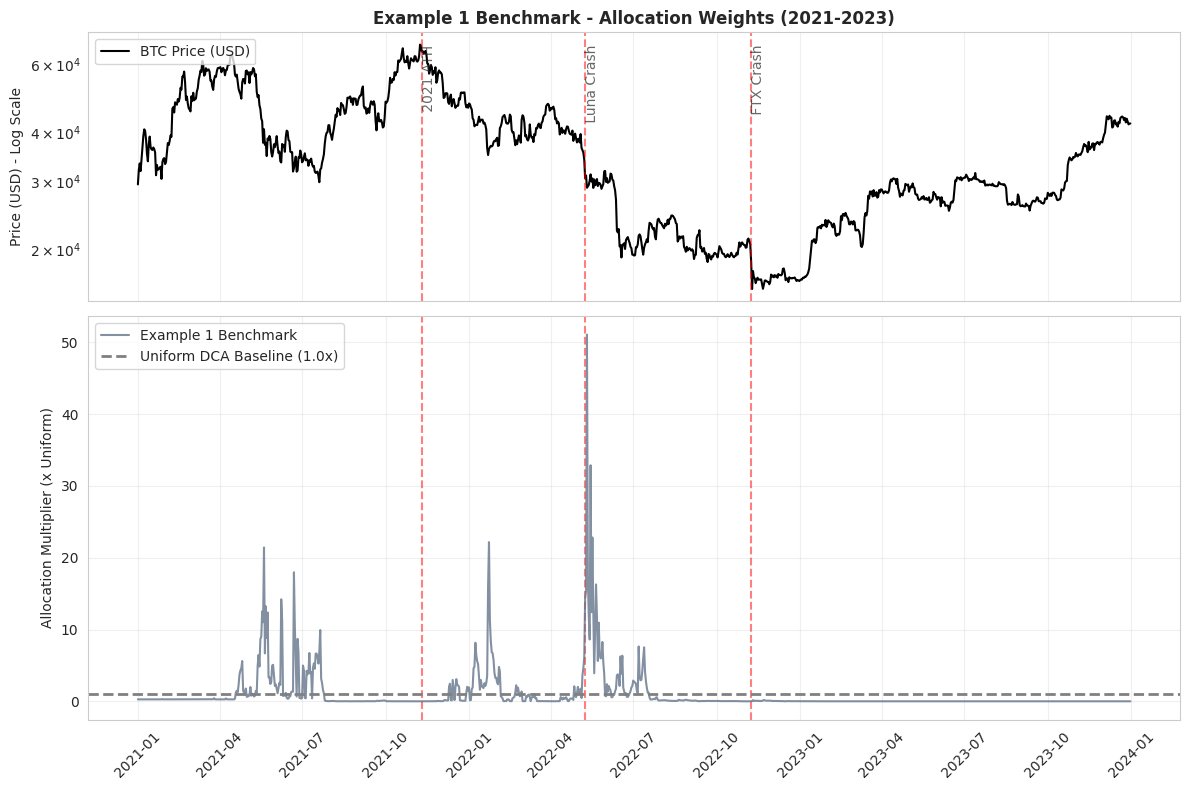

In [3]:
def plot_ex1_weights(name="Example 1 Benchmark", color="#64748b"):
    """Visualise the Example 1 model's allocation behaviour during the 2021-2023 cycle."""
    start_date = pd.Timestamp("2021-01-01")
    end_date = pd.Timestamp("2023-12-31")

    df_window = features_ex1.loc[start_date:end_date].copy()
    
    # Compute weights for this specific window
    weights = wrapper_ex1(df_window)

    # Calculate multiplier vs uniform DCA
    uniform_weight = 1.0 / len(df_window)
    multiplier = weights / uniform_weight

    price = df_window["PriceUSD_coinmetrics"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1.5]})

    # Top subplot: Price
    ax1.plot(price.index, price.values, color='black', linewidth=1.5, label='BTC Price (USD)')
    ax1.set_yscale('log')
    ax1.set_ylabel('Price (USD) - Log Scale')
    ax1.set_title(f'{name} - Allocation Weights (2021-2023)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Highlight events
    events = {'2021 ATH': '2021-11-10', 'Luna Crash': '2022-05-09', 'FTX Crash': '2022-11-08'}
    for ev_name, date in events.items():
        ts = pd.Timestamp(date)
        if ts in price.index:
            ax1.axvline(ts, color='red', linestyle='--', alpha=0.5)
            ax1.text(ts, price.max(), f' {ev_name}', rotation=90, va='top', alpha=0.7)
            ax2.axvline(ts, color='red', linestyle='--', alpha=0.5)

    # Bottom subplot: Multiplier
    ax2.plot(price.index, multiplier, color=color, linewidth=1.5, alpha=0.8, label=name)
    ax2.axhline(1.0, color='gray', linestyle='--', linewidth=2, label='Uniform DCA Baseline (1.0x)')
    ax2.set_ylabel('Allocation Multiplier (x Uniform)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left')

    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.savefig(out_path_ex1 / "allocation_weights.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_ex1_weights()

### Example performance

The example acutally performs very well with a win rate of above 60% which is not easy to achieve in financial markets generally! It will prove a strong baseline to beat.

In [4]:
# Precompute features once to speed up iterative testing for our models
def precompute_all_features(df):
    price = df["PriceUSD_coinmetrics"].loc["2010-07-18":].copy()
    
    # MVRV Z-Score
    mvrv = df["CapMVRVCur"].loc[price.index]
    mvrv_mean = mvrv.rolling(365, min_periods=180).mean()
    mvrv_std = mvrv.rolling(365, min_periods=180).std()
    mvrv_zscore = ((mvrv - mvrv_mean) / mvrv_std).fillna(0).clip(-4, 4)
    
    # Momentum
    roi_30d = price.pct_change(30).fillna(0).clip(-1, 1)
    roi_1yr = price.pct_change(365).fillna(0).clip(-2, 5)
    
    # Volatility
    daily_ret = price.pct_change().fillna(0)
    vol_90d = daily_ret.rolling(90, min_periods=22).std().fillna(0)
    volatility_pct = vol_90d.rolling(360, min_periods=90).apply(
        lambda x: (x.iloc[-1] > x[:-1]).sum() / max(len(x) - 1, 1) if len(x) > 1 else 0.5, raw=False
    ).fillna(0.5)
    
    # Regime & Trajectory
    ma_200 = price.rolling(200, min_periods=100).mean()
    price_vs_ma = (price / ma_200) - 1.0
    price_vs_ma = price_vs_ma.fillna(0).clip(-0.8, 2.0)
    
    gradient_raw = mvrv_zscore.diff(30)
    gradient_smooth = gradient_raw.ewm(span=30, adjust=False).mean()
    mvrv_gradient = np.tanh(gradient_smooth * 2).fillna(0)

    accel_raw = mvrv_gradient.diff(14)
    accel_smooth = accel_raw.ewm(span=14, adjust=False).mean()
    mvrv_acceleration = np.tanh(accel_smooth * 3).fillna(0)
    
    features = pd.DataFrame({
        "PriceUSD_coinmetrics": price,
        "mvrv_zscore": mvrv_zscore,
        "roi_30d": roi_30d,
        "roi_1yr": roi_1yr,
        "volatility_pct": volatility_pct,
        "price_vs_ma": price_vs_ma,
        "mvrv_gradient": mvrv_gradient,
        "mvrv_acceleration": mvrv_acceleration,
        "fed_uncertainty": 0.5 # Placeholder for Polymarket
    }, index=price.index)
    
    signal_cols = ["mvrv_zscore", "roi_30d", "roi_1yr", "volatility_pct", "price_vs_ma", "mvrv_gradient", "mvrv_acceleration", "fed_uncertainty"]
    features[signal_cols] = features[signal_cols].shift(1).fillna(0)
    return features

print("Precomputing features for our models...")
features_df = precompute_all_features(df_btc)

# Evaluation Helper
def evaluate_model(multiplier_func, name="Model", out_dir_name="model"):
    def compute_weights(df):
        if df.empty: return pd.Series(dtype=float)
        
        base = np.ones(len(df)) / len(df)
        z = _clean_array(df["mvrv_zscore"].values)
        r30 = _clean_array(df["roi_30d"].values)
        r1y = _clean_array(df["roi_1yr"].values)
        v = _clean_array(df["volatility_pct"].values)
        pma = _clean_array(df["price_vs_ma"].values)
        g = _clean_array(df["mvrv_gradient"].values)
        a = _clean_array(df["mvrv_acceleration"].values)
        f = _clean_array(df["fed_uncertainty"].values)
        
        dyn = multiplier_func(z, r30, r1y, v, pma, g, a, f)
        raw = base * dyn
        weights = allocate_sequential_stable(raw, len(df), None)
        return pd.Series(weights, index=df.index)

    print(f"Running backtest for {name}...")
    df_spd = compute_cycle_spd(
        dataframe=df_btc,
        strategy_function=compute_weights,
        features_df=features_df,
        start_date="2018-01-01",
        end_date="2025-12-31"
    )
    
    win_rate = (df_spd["dynamic_percentile"] > df_spd["uniform_percentile"]).mean() * 100
    
    dynamic_pct = df_spd["dynamic_percentile"]
    N = len(dynamic_pct)
    exp_weights = 0.9 ** np.arange(N - 1, -1, -1)
    exp_weights /= exp_weights.sum()
    exp_avg_pct = (dynamic_pct.values * exp_weights).sum()
    
    score = (0.5 * win_rate) + (0.5 * exp_avg_pct)
    
    excess_percentile = df_spd["dynamic_percentile"] - df_spd["uniform_percentile"]
    uniform_pct_safe = df_spd["uniform_percentile"].replace(0, 0.01)
    relative_improvements = excess_percentile / uniform_pct_safe * 100
    
    metrics = {
        'score': score,
        'win_rate': win_rate,
        'exp_decay_percentile': exp_avg_pct,
        'mean_excess': excess_percentile.mean(),
        'median_excess': excess_percentile.median(),
        'relative_improvement_pct_mean': relative_improvements.mean(),
        'relative_improvement_pct_median': relative_improvements.median(),
        'mean_ratio': (df_spd['dynamic_percentile'] / df_spd['uniform_percentile']).mean(),
        'median_ratio': (df_spd['dynamic_percentile'] / df_spd['uniform_percentile']).median(),
        'total_windows': len(df_spd),
        'wins': (df_spd["dynamic_percentile"] > df_spd["uniform_percentile"]).sum(),
        'losses': (df_spd["dynamic_percentile"] <= df_spd["uniform_percentile"]).sum()
    }
    
    # Create specific output directory for this version
    out_path = Path("output_notebook") / out_dir_name
    out_path.mkdir(parents=True, exist_ok=True)
    
    # Generate the metrics summary chart
    create_performance_metrics_summary(df_spd, metrics, str(out_path))
    
    print(f"--- Results: {name} ---")
    print(f"Final Model Score: {score:.2f}%")
    print(f"Win Rate: {win_rate:.2f}%")
    print(f"Excess percentile: mean={excess_percentile.mean():.2f}%, median={excess_percentile.median():.2f}%")
    print(f"Relative improvement: mean={relative_improvements.mean():.2f}%, median={relative_improvements.median():.2f}%")
    print(f"Ratio (dynamic/uniform): mean={(df_spd['dynamic_percentile'] / df_spd['uniform_percentile']).mean():.2f}, median={(df_spd['dynamic_percentile'] / df_spd['uniform_percentile']).median():.2f}\n")
    return df_spd, metrics

Precomputing features for our models...


In [5]:
def plot_model_weights(multiplier_func, name, out_dir_name, color='#10b981'):
    """Visualise the model's allocation behaviour during the 2021-2023 cycle."""
    start_date = pd.Timestamp("2021-01-01")
    end_date = pd.Timestamp("2023-12-31")

    df_window = features_df.loc[start_date:end_date].copy()  # noqa: F821

    # Compute weights for this specific window
    base = np.ones(len(df_window)) / len(df_window)
    z = _clean_array(df_window["mvrv_zscore"].values)
    r30 = _clean_array(df_window["roi_30d"].values)
    r1y = _clean_array(df_window["roi_1yr"].values)
    v = _clean_array(df_window["volatility_pct"].values)
    pma = _clean_array(df_window["price_vs_ma"].values)
    g = _clean_array(df_window["mvrv_gradient"].values)
    a = _clean_array(df_window["mvrv_acceleration"].values)
    f = _clean_array(df_window["fed_uncertainty"].values)

    dyn = multiplier_func(z, r30, r1y, v, pma, g, a, f)
    raw = base * dyn
    weights = allocate_sequential_stable(raw, len(df_window), None)

    # Calculate multiplier vs uniform DCA
    uniform_weight = 1.0 / len(df_window)
    multiplier = weights / uniform_weight

    price = df_window["PriceUSD_coinmetrics"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1.5]})

    # Top subplot: Price
    ax1.plot(price.index, price.values, color='black', linewidth=1.5, label='BTC Price (USD)')
    ax1.set_yscale('log')
    ax1.set_ylabel('Price (USD) - Log Scale')
    ax1.set_title(f'{name} - Allocation Weights (2021-2023)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Highlight events
    events = {'2021 ATH': '2021-11-10', 'Luna Crash': '2022-05-09', 'FTX Crash': '2022-11-08'}
    for ev_name, date in events.items():
        ts = pd.Timestamp(date)
        if ts in price.index:
            ax1.axvline(ts, color='red', linestyle='--', alpha=0.5)
            ax1.text(ts, price.max(), f' {ev_name}', rotation=90, va='top', alpha=0.7)
            ax2.axvline(ts, color='red', linestyle='--', alpha=0.5)

    # Bottom subplot: Multiplier
    ax2.plot(price.index, multiplier, color=color, linewidth=1.5, alpha=0.8, label=name)
    ax2.axhline(1.0, color='gray', linestyle='--', linewidth=2, label='Uniform DCA Baseline (1.0x)')
    ax2.set_ylabel('Allocation Multiplier (x Uniform)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left')

    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    out_path = Path("output_notebook") / out_dir_name
    out_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path / "allocation_weights.png", dpi=300, bbox_inches='tight')
    plt.show()



## 1. The Starting Point (Baseline)

Our initial model relied primarily on the MVRV Z-score and basic return momentum, which is what our EDA revealed as being some of the strongest factors. While it achieved a win rate of ~60%, its mean excess Sats-Per-Dollar (SPD) was relatively low. It was buying more during cheap periods, but it wasn't aggressive enough during structural market lows.

**Mathematical Implementation:**
- $S_{value} = -Z$
- $Boost = (Z + 1.5)^2$ if $Z < -1.5$ else $0$
- $S_{mom} = 1.5 \times R_{30} + 0.25 \times R_{365}$
- $Combined = 0.75 \times (S_{value} + Boost) + 0.25 \times S_{mom}$
- $Dampener = 1.0 - 0.4 \times \frac{V - 0.8}{0.2}$ if $V > 0.8$ else $1.0$
- $Multiplier = \exp(\text{clip}(Combined \times 3.5, -4, 10)) \times Dampener$

In [6]:
def multiplier_v1(z, r30, r1y, v, pma, g, a, f):
    mvrv_signal = -z
    mvrv_boost = np.where(z < -1.5, (z + 1.5)**2, 0)
    mom_signal = (r30 * 1.5) + (r1y * 0.25)
    
    combined = ((mvrv_signal + mvrv_boost) * 0.75) + (mom_signal * 0.25)
    
    dampener = np.where(v > 0.8, 1.0 - 0.4 * ((v - 0.8) / 0.2), 1.0)
    
    adjustment = np.clip(combined * 3.5, -4, 10)
    multiplier = np.exp(adjustment) * dampener
    return np.where(np.isfinite(multiplier), multiplier, 1.0)

df_spd_v1, metrics_v1 = evaluate_model(multiplier_v1, "V1: Baseline", "v1_baseline")

2026-04-16 00:10:24 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


Running backtest for V1: Baseline...


2026-04-16 00:10:33 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:10:34 INFO     ✓ Saved: output_notebook/v1_baseline/metrics_summary.svg


--- Results: V1: Baseline ---
Final Model Score: 58.60%
Win Rate: 62.18%
Excess percentile: mean=4.02%, median=6.97%
Relative improvement: mean=12.09%, median=17.05%
Ratio (dynamic/uniform): mean=1.12, median=1.17



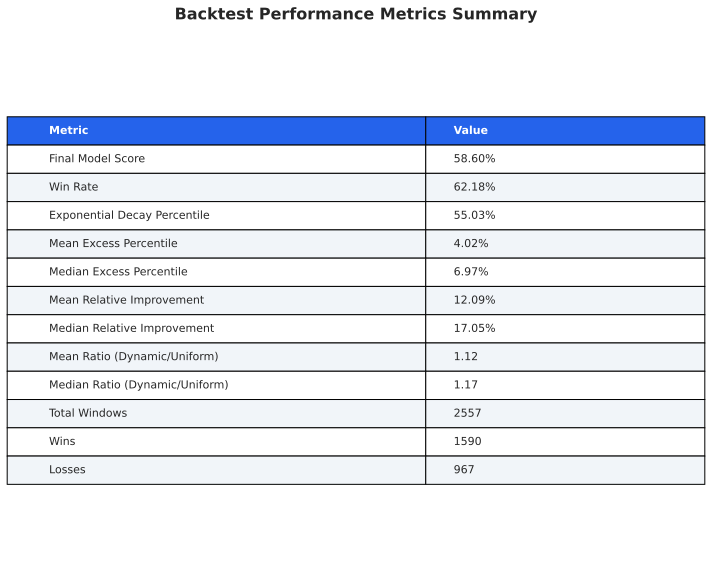

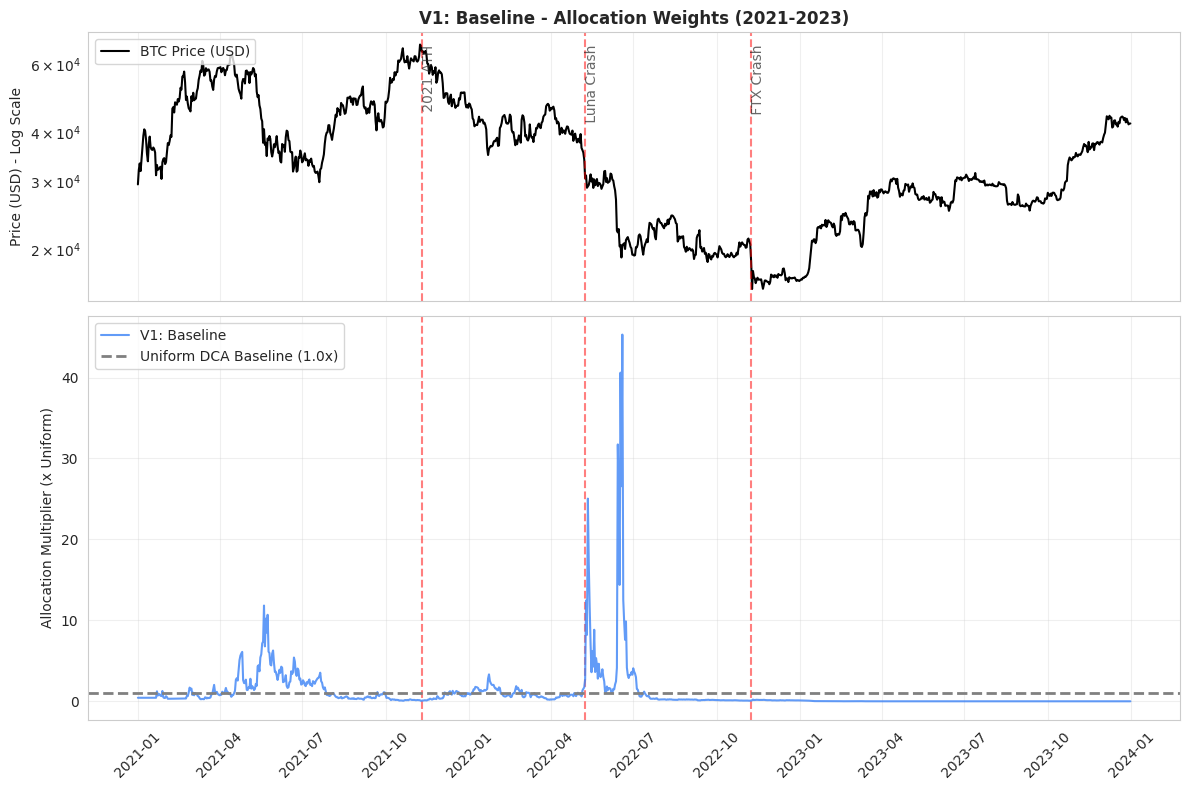

In [7]:
display(SVG(filename="output_notebook/v1_baseline/metrics_summary.svg"))
plot_model_weights(multiplier_v1, "V1: Baseline", "v1_baseline", color="#3b82f6")

## 2. Iteration 1: Regime & Trajectory (The "Sniper" Model)

Based on our EDA, we knew the 200-day Moving Average was a powerful regime filter, and the *change* in MVRV (gradient) was crucial for confirming bottoms. We added these features. 

**The Result:** The model became a "sniper". It saved all its capital for the absolute bottom day of a crash (spiking to 95x normal allocation), but starved the rest of the bear market. The score dropped slightly because it was too concentrated.

**Mathematical Implementation:**
- $Bottom\_Conf = Boost \times 0.75$ if ($Z < -1.5$ AND $g > 0$) else $0$
- $Regime\_Mult = 1.0 + |PMA|$ if $PMA < 0$ else $\max(0.05, 1.0 - PMA)$
- $Combined = [0.75 \times (S_{value} + Boost + Bottom\_Conf) + 0.25 \times S_{mom}] \times Regime\_Mult$

In [8]:
def multiplier_v2(z, r30, r1y, v, pma, g, a, f):
    mvrv_signal = -z
    deep_value = z < -1.5
    improving = g > 0
    
    mvrv_boost = np.where(deep_value, (z + 1.5)**2, 0)
    bottom_confirmation = np.where(deep_value & improving, mvrv_boost * 0.75, 0)
    
    # Multiplicative regime modifier
    regime_multiplier = np.where(pma < 0, 1.0 + np.abs(pma), np.maximum(0.05, 1.0 - pma))
    
    combined = ((mvrv_signal + mvrv_boost + bottom_confirmation) * 0.75) + ((r30 * 1.5 + r1y * 0.25) * 0.25)
    combined = combined * regime_multiplier
    
    adjustment = np.clip(combined * 3.5, -4, 10)
    multiplier = np.exp(adjustment)
    return np.where(np.isfinite(multiplier), multiplier, 1.0)

df_spd_v2, metrics_v2 = evaluate_model(multiplier_v2, "V2: The Sniper", "v2_sniper")

2026-04-16 00:10:35 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


Running backtest for V2: The Sniper...


2026-04-16 00:10:45 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:10:45 INFO     ✓ Saved: output_notebook/v2_sniper/metrics_summary.svg


--- Results: V2: The Sniper ---
Final Model Score: 58.69%
Win Rate: 62.65%
Excess percentile: mean=5.09%, median=7.03%
Relative improvement: mean=15.85%, median=15.44%
Ratio (dynamic/uniform): mean=1.16, median=1.15



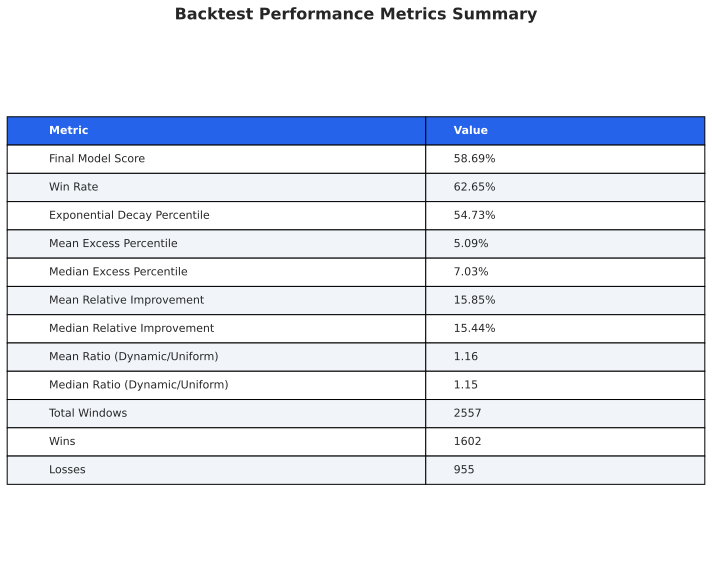

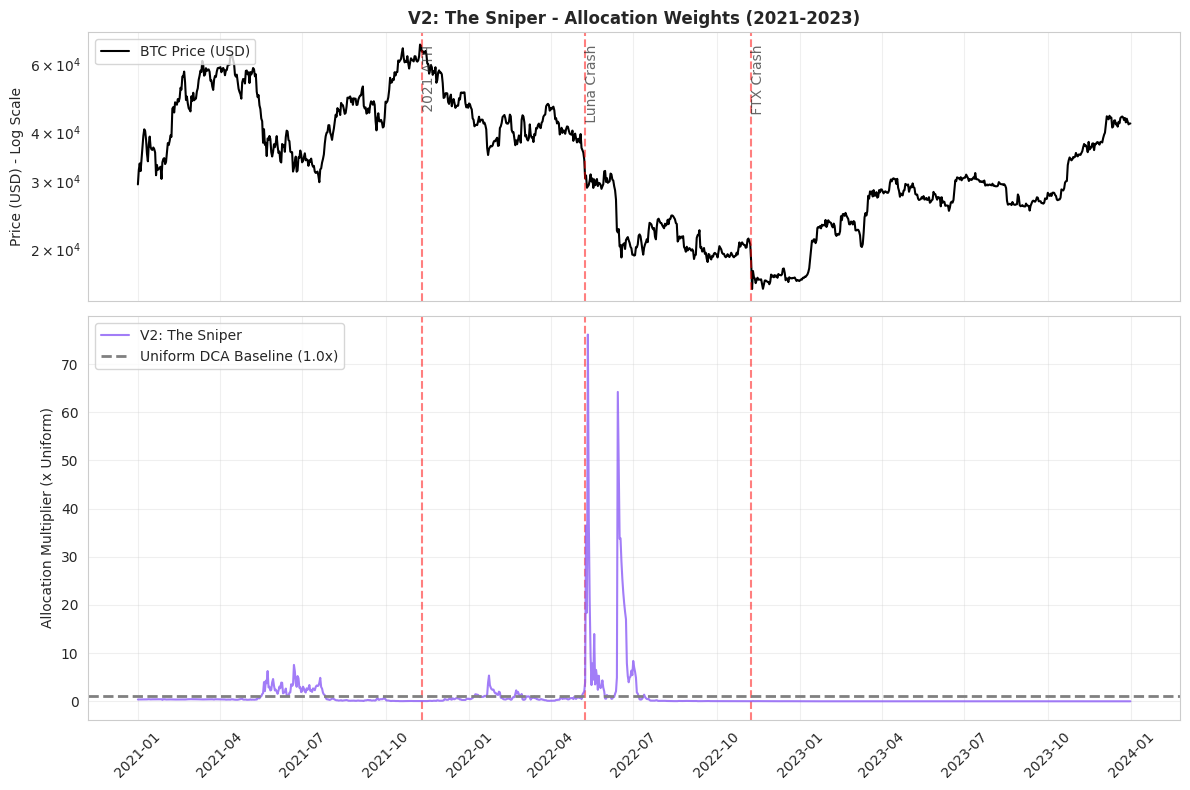

In [9]:
display(SVG(filename="output_notebook/v2_sniper/metrics_summary.svg"))
plot_model_weights(multiplier_v2, "V2: The Sniper", "v2_sniper", color="#8b5cf6")

## 3. Iteration 2: The Multiplicative Bug

To fix the "sniper" issue, we attempted to implement *Regime-Conditional Blending*—weighting value heavily in bear markets and momentum heavily in bull markets. 

**The Bug:** We kept the regime modifier as a multiplier (`combined * regime_multiplier`). At the peak of a bull market, the base signal is deeply negative (e.g., `-3.0`, meaning "do not buy"). Multiplying this by a small regime fraction (e.g., `0.05`) shrank the signal to `-0.15`. When exponentiated, `exp(-0.15)` is close to `1.0x`. We accidentally forced the model to buy at normal DCA rates right at the market top! Performance plummeted.

**Mathematical Implementation:**
- $S_{value} = -Z + |Z|^{1.5}$ if ($Z < -1.0$ AND $g > 0$) else $-Z$
- $S_{mom} = 2.0 \times R_{30} + 0.5 \times R_{365}$
- $Base\_Signal = 0.8 \times S_{value} + 0.2 \times S_{mom}$ if $PMA < 0$ else $0.4 \times S_{value} + 0.6 \times S_{mom}$
- $Regime\_Mult = 1.0 + |PMA| \times 2.0$ if $PMA < 0$ else $\max(0.2, 1.0 - PMA \times 0.75)$
- $Combined = Base\_Signal \times Regime\_Mult$ (This multiplication is the bug!)

In [10]:
def multiplier_v3(z, r30, r1y, v, pma, g, a, f):
    value_score = -z + np.where((z < -1.0) & (g > 0), np.abs(z)**1.5, 0)
    mom_score = (r30 * 2.0) + (r1y * 0.5)
    
    is_bear = pma < 0
    combined = np.where(is_bear, 
                      (value_score * 0.8) + (mom_score * 0.2), 
                      (value_score * 0.4) + (mom_score * 0.6))
    
    # The Bug: Multiplicative scaling of a signal that crosses zero
    regime_multiplier = np.where(is_bear, 1.0 + np.abs(pma) * 2.0, np.maximum(0.2, 1.0 - pma * 0.75))
    combined = combined * regime_multiplier
    
    adjustment = np.clip(combined * 2.0, -3, 5)
    multiplier = np.exp(adjustment)
    return np.where(np.isfinite(multiplier), multiplier, 1.0)

df_spd_v3, metrics_v3 = evaluate_model(multiplier_v3, "V3: Multiplicative Bug", "v3_bug")

2026-04-16 00:10:46 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


Running backtest for V3: Multiplicative Bug...


2026-04-16 00:10:56 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:10:56 INFO     ✓ Saved: output_notebook/v3_bug/metrics_summary.svg


--- Results: V3: Multiplicative Bug ---
Final Model Score: 53.77%
Win Rate: 53.62%
Excess percentile: mean=2.41%, median=1.76%
Relative improvement: mean=8.00%, median=4.52%
Ratio (dynamic/uniform): mean=1.08, median=1.05



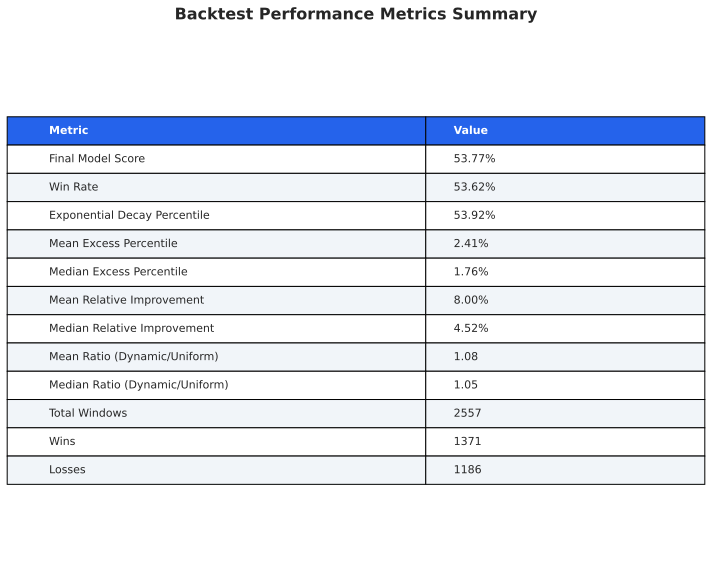

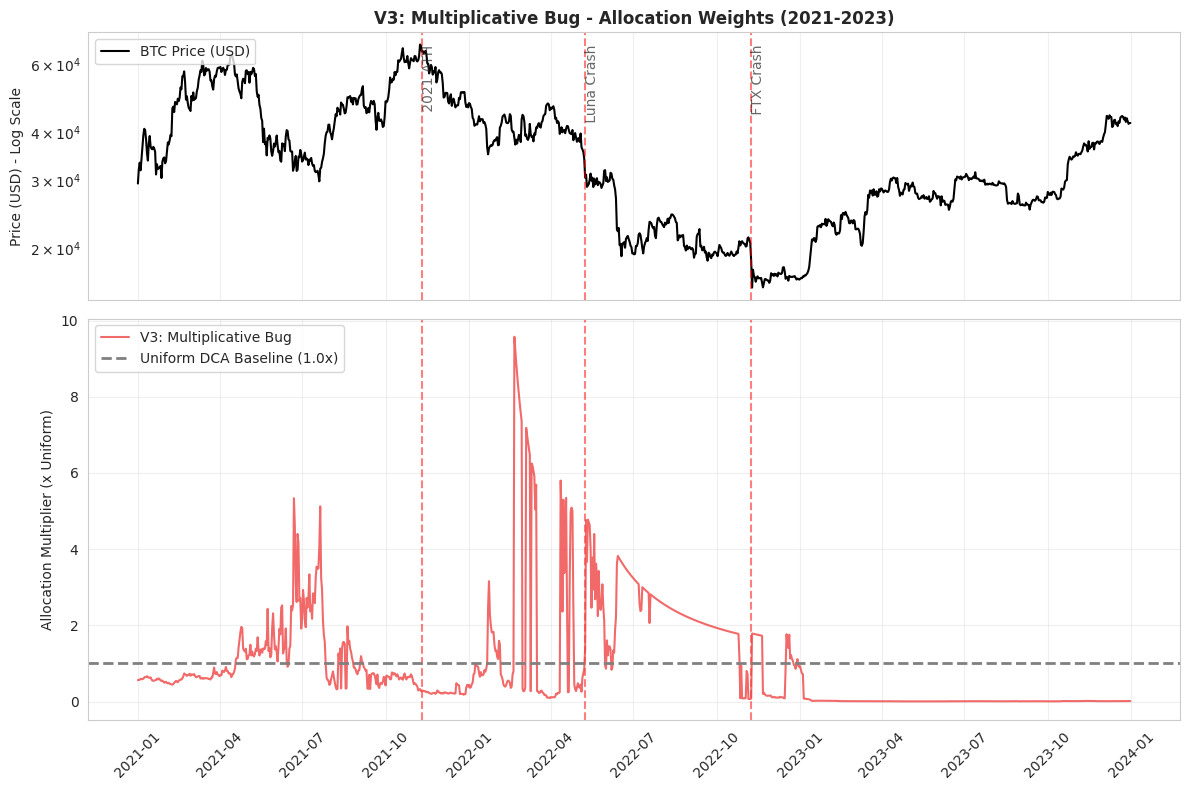

In [11]:
display(SVG(filename="output_notebook/v3_bug/metrics_summary.svg"))
plot_model_weights(multiplier_v3, "V3: Multiplicative Bug", "v3_bug", color="#ef4444")

#### 4. Iteration 3: Log-Space Additivity

To fix the bug, we realised that because we exponentiate the final output, we must apply the regime shift **additively in log-space**. 

Because `exp(A + B) = exp(A) * exp(B)`, adding a penalty in log-space acts as a true multiplier in real-space. This preserves the direction and magnitude of the "do not buy" signal at market tops, while boosting accumulation at market bottoms.

**The Result:** A good breakthrough. The score jumped past 60%, with a win rate of 64% and a median relative improvement of >14%.

**Mathematical Implementation:**
- $Base\_Signal = 0.8 \times S_{value} + 0.2 \times S_{mom}$
- $Regime\_Shift = |PMA| \times 2.0$ if $PMA < 0$ else $-PMA \times 3.0$
- $Combined = Base\_Signal + Regime\_Shift$ (Additive shift in log-space)
- $Multiplier = \exp(\text{clip}(Combined \times 2.5 \times Dampener, -4.0, 4.5))$

In [12]:
def multiplier_v4(z, r30, r1y, v, pma, g, a, f):
    value_score = -z
    deep_value = z < -1.0
    improving = g > 0
    
    value_boost = np.where(deep_value, np.abs(z) - 1.0, 0)
    confirmation_boost = np.where(deep_value & improving, value_boost * 1.0, 0)
    value_score = value_score + value_boost + confirmation_boost

    mom_score = r30 * 2.0
    base_signal = (value_score * 0.8) + (mom_score * 0.2)

    # The Fix: Additive shift in log-space
    regime_shift = np.where(pma < 0, np.abs(pma) * 2.0, -pma * 3.0)
    combined = base_signal + regime_shift

    dampener = np.where(v > 0.85, 1.0 - 0.5 * ((v - 0.85) / 0.15), 1.0)
    
    adjustment = np.clip(combined * 2.5 * dampener, -4.0, 4.5)
    multiplier = np.exp(adjustment)
    return np.where(np.isfinite(multiplier), multiplier, 1.0)

df_spd_v4, metrics_v4 = evaluate_model(multiplier_v4, "V4: Log-Space Additivity", "v4_log_space")

2026-04-16 00:10:57 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


Running backtest for V4: Log-Space Additivity...


2026-04-16 00:11:07 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:11:07 INFO     ✓ Saved: output_notebook/v4_log_space/metrics_summary.svg


--- Results: V4: Log-Space Additivity ---
Final Model Score: 60.31%
Win Rate: 63.94%
Excess percentile: mean=5.07%, median=6.96%
Relative improvement: mean=13.76%, median=17.97%
Ratio (dynamic/uniform): mean=1.14, median=1.18



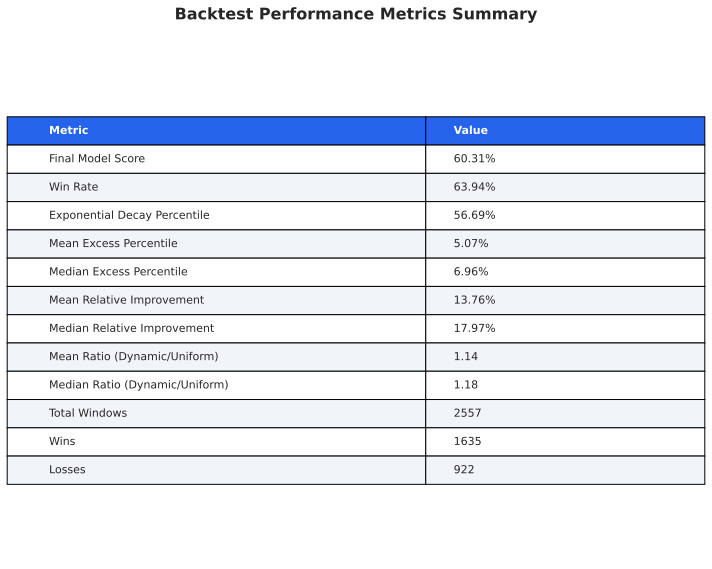

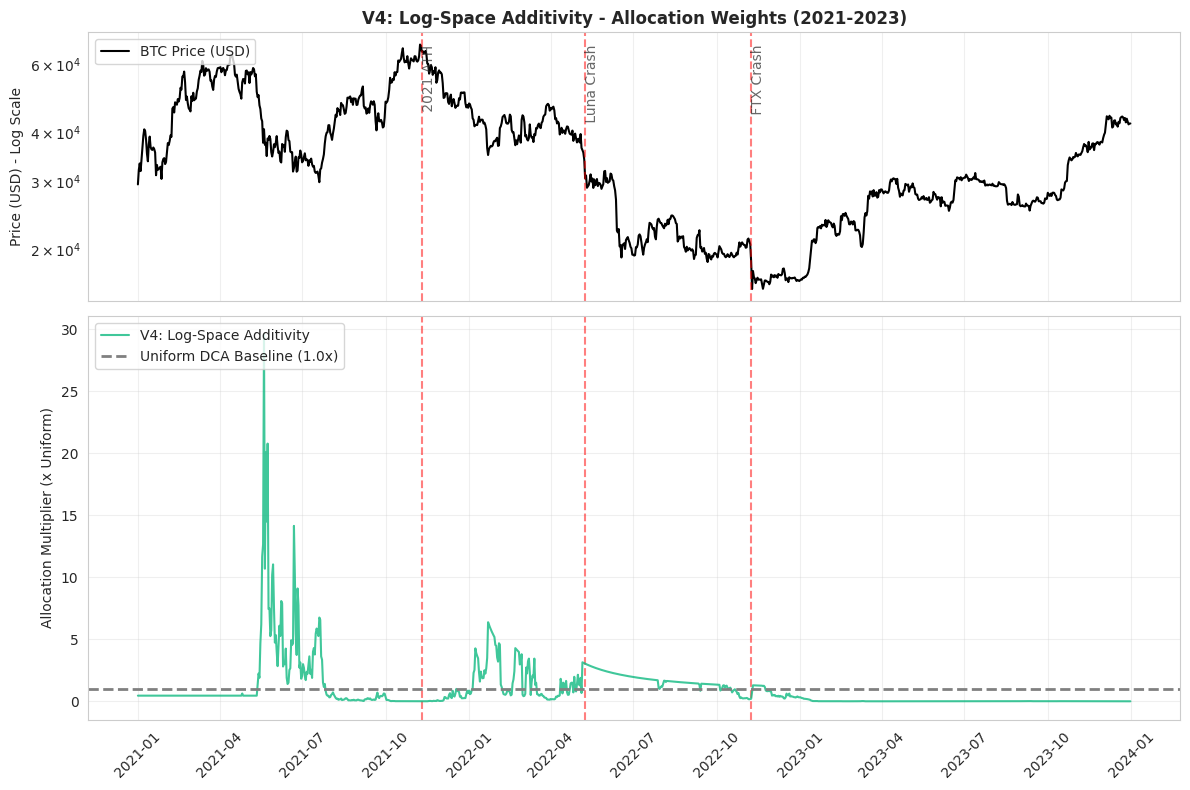

In [13]:
display(SVG(filename="output_notebook/v4_log_space/metrics_summary.svg"))
plot_model_weights(multiplier_v4, "V4: Log-Space Additivity", "v4_log_space", color="#10b981")

## 5. Iteration 4: Advanced Signal Processing (The Final Model)

While V4 was a massive breakthrough, we noticed it could still be optimised. By incorporating insights from our benchmark (Example 1), we added:
1. **Smoothed Gradient & Acceleration** to detect momentum building/reversing.
2. **Asymmetric Extreme Boosts** (quadratic scaling for deep value/danger).
3. **Signal Confidence** (agreement between MVRV and 200 DMA).

**The Result:** This pushed our win rate to an exceptional 66.68% and our final score to 61.66%.

**Mathematical Implementation:**
- **Asymmetric Extreme Boosts:**
  - If $Z < -2.0$: $Boost = 0.8 \times (Z + 2.0)^2 + 0.5$
  - If $-2.0 \le Z < -1.0$: $Boost = -0.5 \times Z$
  - If $1.5 \le Z < 2.5$: $Boost = -0.3 \times (Z - 1.5)$
  - If $Z \ge 2.5$: $Boost = -0.5 \times (Z - 2.5)^2 - 0.3$
- **Acceleration Modifier:**
  - $Accel\_Mod = 1.0 + 0.3 \times |a|$ if $a \times g > 0$ else $1.0 - 0.2 \times |a|$
- **Signal Confidence:**
  - $Confidence = 0.7 \times Agreement + 0.3 \times Gradient\_Alignment$
  - $Conf\_Boost = 1.0 + 0.15 \times \frac{Confidence - 0.7}{0.3}$ if $Confidence > 0.7$ else $1.0$
- $Combined = (Base\_Signal + Regime\_Shift) \times Accel\_Mod \times Conf\_Boost$

In [14]:
def multiplier_v5(z, r30, r1y, v, pma, g, a, f):
    # 1. Value Score (MVRV)
    value_score = -z
    
    # Asymmetric Extreme Boost
    boost = np.zeros_like(z)
    boost = np.where(z < -2.0, 0.8 * (z + 2.0)**2 + 0.5, boost)
    boost = np.where((z >= -2.0) & (z < -1.0), -0.5 * z, boost)
    boost = np.where((z >= 1.5) & (z < 2.5), -0.3 * (z - 1.5), boost)
    boost = np.where(z >= 2.5, -0.5 * (z - 2.5)**2 - 0.3, boost)
    
    improving = g > 0
    confirmation_boost = np.where((z < -1.0) & improving, np.abs(z) * 0.5, 0)
    value_score = value_score + boost + confirmation_boost

    # 2. Momentum Score
    mom_score = r30 * 2.0

    # 3. Combine Base Signals
    base_signal = (value_score * 0.8) + (mom_score * 0.2)

    # 4. Regime Shift (Additive in log-space)
    regime_shift = np.where(pma < 0, np.abs(pma) * 2.0, -pma * 3.0)
    combined = base_signal + regime_shift

    # 5. Acceleration & Confidence Modifiers
    same_direction = (a * g) > 0
    accel_modifier = np.where(same_direction, 1.0 + 0.3 * np.abs(a), 1.0 - 0.2 * np.abs(a))
    
    z_signal = -z / 4.0
    ma_signal = -pma
    gradient_alignment = np.where(z_signal < 0, np.where(g > 0, 1.0, 0.5), np.where(g < 0, 1.0, 0.5))
    signal_std = np.std([z_signal, ma_signal], axis=0)
    agreement = 1.0 - np.clip(signal_std, 0, 1)
    confidence = agreement * 0.7 + gradient_alignment * 0.3
    
    confidence_boost = np.where(confidence > 0.7, 1.0 + 0.15 * (confidence - 0.7) / 0.3, 1.0)

    combined = combined * accel_modifier * confidence_boost

    # 6. Volatility Dampening
    dampener = np.where(v > 0.85, 1.0 - 0.5 * ((v - 0.85) / 0.15), 1.0)
    
    adjustment = np.clip(combined * 2.5 * dampener, -4.0, 4.5)
    multiplier = np.exp(adjustment)
    return np.where(np.isfinite(multiplier), multiplier, 1.0)

df_spd_v5, metrics_v5 = evaluate_model(multiplier_v5, "V5: Advanced Signal Processing (Final Model)", "v5_final")

2026-04-16 00:11:08 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


Running backtest for V5: Advanced Signal Processing (Final Model)...


2026-04-16 00:11:19 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-04-16 00:11:19 INFO     ✓ Saved: output_notebook/v5_final/metrics_summary.svg


--- Results: V5: Advanced Signal Processing (Final Model) ---
Final Model Score: 61.66%
Win Rate: 66.68%
Excess percentile: mean=4.91%, median=6.22%
Relative improvement: mean=13.31%, median=15.28%
Ratio (dynamic/uniform): mean=1.13, median=1.15



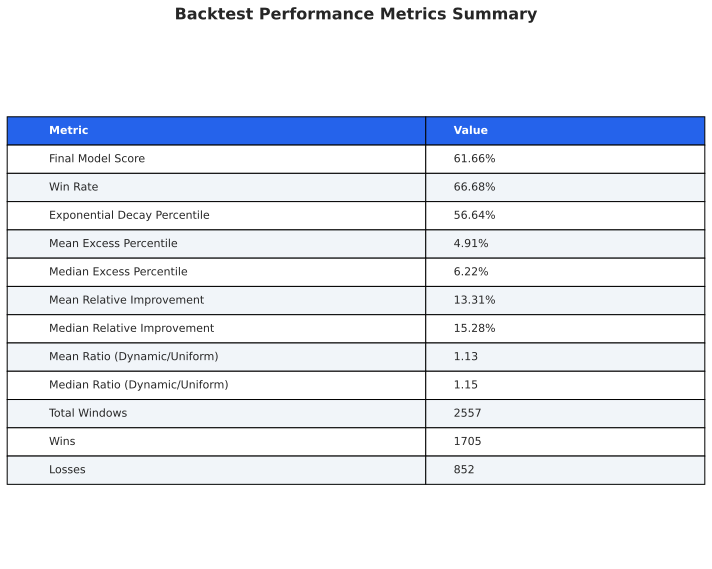

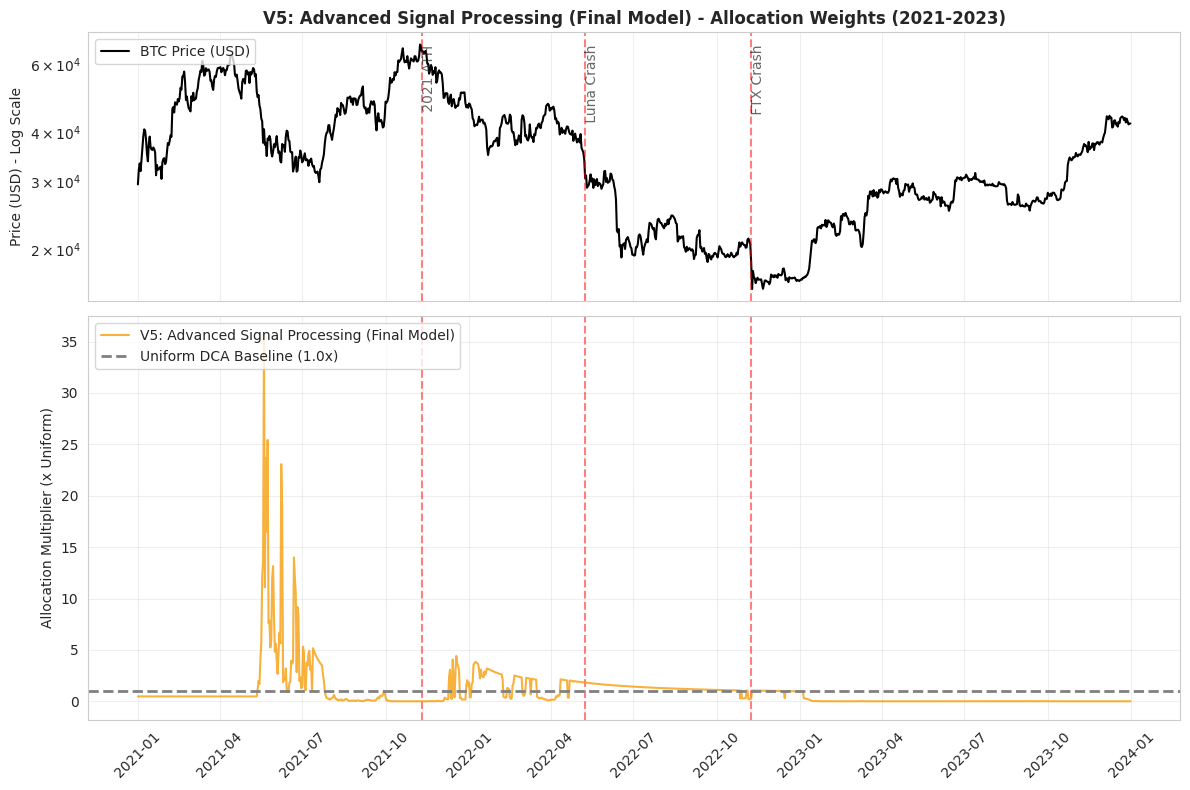

In [15]:
display(SVG(filename="output_notebook/v5_final/metrics_summary.svg"))
plot_model_weights(multiplier_v5, "V5: Advanced Signal Processing (Final Model)", "v5_final", color="#f59e0b")

## 6. Iteration 5: The Polymarket Null Result

Finally, we tested integrating Polymarket Fed Uncertainty. Our EDA suggested high macro uncertainty predicts lower forward volatility, which could allow us to safely buy during chaotic periods.

**The Result:** The impact was negligible. Why? The Polymarket odds history only covers 2023-2026, and the volatility dampener is a rare trigger. As our EDA warned, prediction market data proved coincident rather than incrementally predictive over MVRV. 

In the interest of model parsimony and empirical rigour, we discarded this feature and accepted the null result. **V5 remains our final model.**

## 7. Final Visualisations

To conclude, we generate the standard suite of performance charts for our final V5 model, demonstrating its consistency and magnitude of outperformance against uniform DCA.

In [16]:
print("Generating final performance charts...")
out_path_final = Path("output_notebook") / "v5_final"
create_performance_comparison_chart(df_spd_v5, str(out_path_final))
create_excess_percentile_distribution(df_spd_v5, str(out_path_final))
create_win_loss_comparison(df_spd_v5, str(out_path_final))
create_cumulative_performance(df_spd_v5, str(out_path_final))

Generating final performance charts...


2026-04-16 00:11:20 INFO     ✓ Saved: output_notebook/v5_final/performance_comparison.svg
2026-04-16 00:11:20 INFO     ✓ Saved: output_notebook/v5_final/excess_percentile_distribution.svg
2026-04-16 00:11:21 INFO     ✓ Saved: output_notebook/v5_final/win_loss_comparison.svg
2026-04-16 00:11:21 INFO     ✓ Saved: output_notebook/v5_final/cumulative_performance.svg


### Performance Comparison
This chart shows the distribution of Sats-Per-Dollar (SPD) across all rolling windows.

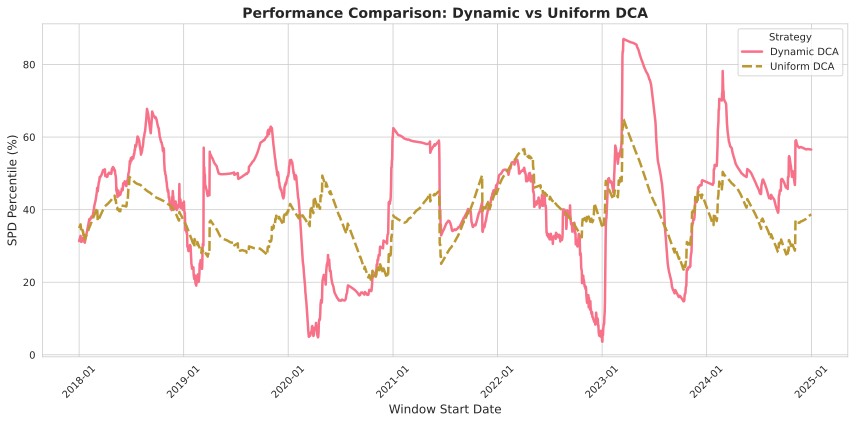

In [17]:
display(SVG(filename=str(out_path_final / "performance_comparison.svg")))

### Excess Percentile Distribution
This highlights the magnitude of outperformance. A right-skewed distribution indicates the strategy consistently acquires more Bitcoin than the baseline.

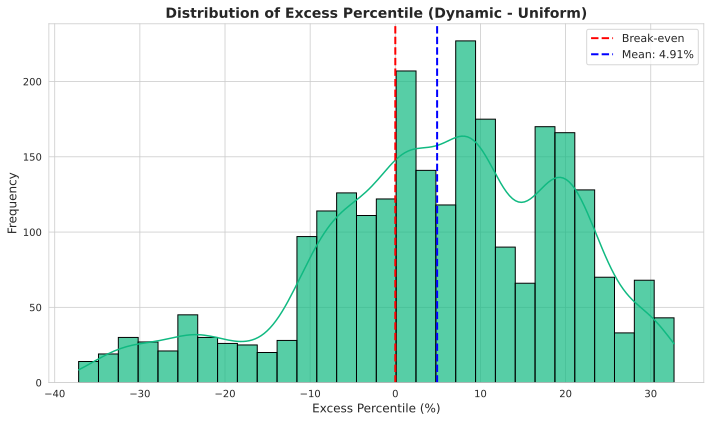

In [18]:
display(SVG(filename=str(out_path_final / "excess_percentile_distribution.svg")))

### Win/Loss Comparison
A breakdown of how often the strategy beats the uniform DCA baseline.

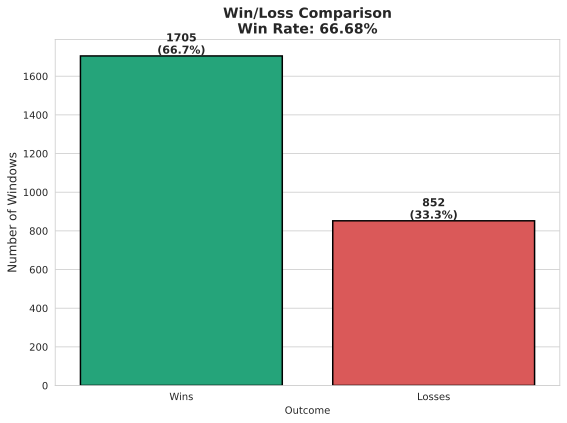

In [19]:
display(SVG(filename=str(out_path_final / "win_loss_comparison.svg")))

### Cumulative Performance
Tracking the cumulative advantage of the dynamic strategy over time.

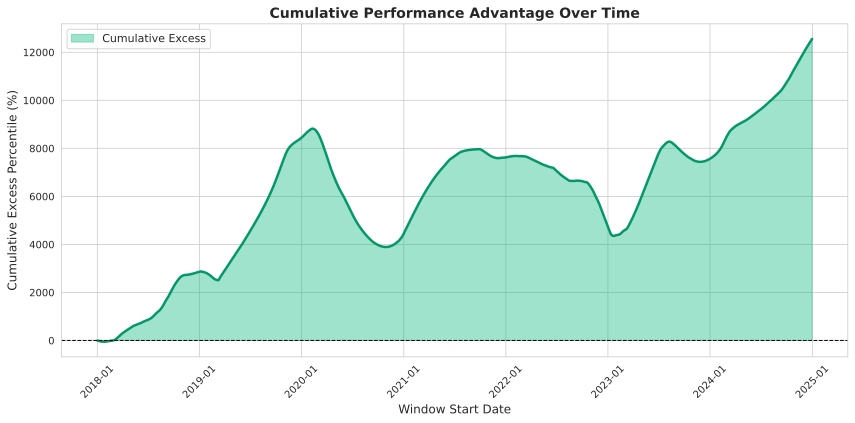

In [20]:
display(SVG(filename=str(out_path_final / "cumulative_performance.svg")))